<a href="https://colab.research.google.com/github/caamilo03/wine-quality/blob/main/sp_1_Camilo_Loaiza_Sarai_Restrepo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Análisis Exploratorio de la Calidad del Vino


## 1. Introducción y planteamiento del problema


La calidad del vino es el resultado de múltiples factores fisicoquímicos que influyen directamente en sus propiedades sensoriales, tales como el sabor, el aroma y la textura, así como en la percepción del consumidor. Tradicionalmente, la evaluación de esta calidad ha sido realizada por expertos mediante catas, un proceso que, aunque efectivo, puede presentar cierto grado de subjetividad y limitaciones en términos de estandarización.


En este contexto, el análisis de datos y las técnicas de ciencia de datos permiten abordar el estudio de la calidad del vino desde una perspectiva cuantitativa, utilizando variables medibles para comprender y modelar su comportamiento. El uso de bases de datos como *Wine Quality – Vinho Verde* posibilita explorar la relación entre distintas características fisicoquímicas y la calidad percibida del vino.


A partir de lo anterior, surge la siguiente pregunta de investigación:


**¿Qué variables permiten predecir de mejor manera la calidad del vino?**

---


In [ ]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url_red = 'https://raw.githubusercontent.com/caamilo03/wine-quality/main/datos/winequality-red.csv'
url_white = 'https://raw.githubusercontent.com/caamilo03/wine-quality/main/datos/winequality-white.csv'

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
# Número de registros y variables
print("== Vino rojo ==")
print(f"Número de registros: {df_red.shape[0]}")
print(f"Número de variables: {df_red.shape[1]}")
print("")

print("== Vino blanco ==")
print(f"Número de registros: {df_white.shape[0]}")
print(f"Número de variables: {df_white.shape[1]}")

== Vino rojo ==
Número de registros: 1599
Número de variables: 12

== Vino blanco ==
Número de registros: 4898
Número de variables: 12


In [ ]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_red.dtypes.value_counts())
print(df_red.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64
float64    11
int64       1
Name: count, dtype: int64


In [ ]:
# Clasificación de variables
categoricas = df_red.select_dtypes(include=['object']).columns.tolist()
numericas = df_red.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(" == Variables categóricas ==")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n == Variables numéricas ==")
print("\n".join([f"- {col}" for col in numericas]))

 == Variables categóricas ==


 == Variables numéricas ==
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality


## 2. Descripción de la Base de Datos

Este proyecto utiliza el conjunto de datos **Wine Quality**, el cual está dividido en dos archivos principales correspondientes a variantes del vino portugués "Vinho Verde":
* `winequality-red.csv`: Datos de muestras de vino tinto.
* `winequality-white.csv`: Datos de muestras de vino blanco

- **Total de registros:** 6,497 observaciones
- **Total de variables:** 12 características

Cada registro representa una muestra de vino, acompañada de distintas mediciones fisicoquímicas y su respectiva evaluación de calidad.


In [ ]:
# Número de registros y variables
print("== Vino rojo ==")
print(f"Número de registros: {df_red.shape[0]}")
print(f"Número de variables: {df_red.shape[1]}")
print("")

print("== Vino blanco ==")
print(f"Número de registros: {df_white.shape[0]}")
print(f"Número de variables: {df_white.shape[1]}")

== Vino rojo ==
Número de registros: 1599
Número de variables: 12

== Vino blanco ==
Número de registros: 4898
Número de variables: 12


#3. Descripción de las variables


### 3.1 Variables continuas
- `fixed acidity`
- `volatile acidity`
- `citric acid`
- `residual sugar`
- `chlorides`
- `free sulfur dioxide`
- `total sulfur dioxide`
- `density`
- `pH`
- `sulphates`
- `alcohol`


Estas variables corresponden a propiedades químicas y físicas del vino que pueden influir directamente en su sabor, aroma y estabilidad.


### 3.2 Variables categóricas
- `quality`
- `color`


In [ ]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_red.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64
float64    11
int64       1
Name: count, dtype: int64


In [ ]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_white.dtypes.value_counts())
print(df_white.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64
float64    11
int64       1
Name: count, dtype: int64


# 4. Variable de interés
La variable central de esta investigación es **`quality`**, la cual representa la **calidad del vino**, evaluada a partir de criterios sensoriales.


El objetivo del estudio se centra en **analizar la relación entre la calidad del vino y el resto de las variables**, con el fin de identificar cuáles de ellas ejercen una mayor influencia y poseen un mayor poder predictivo sobre dicha calidad.




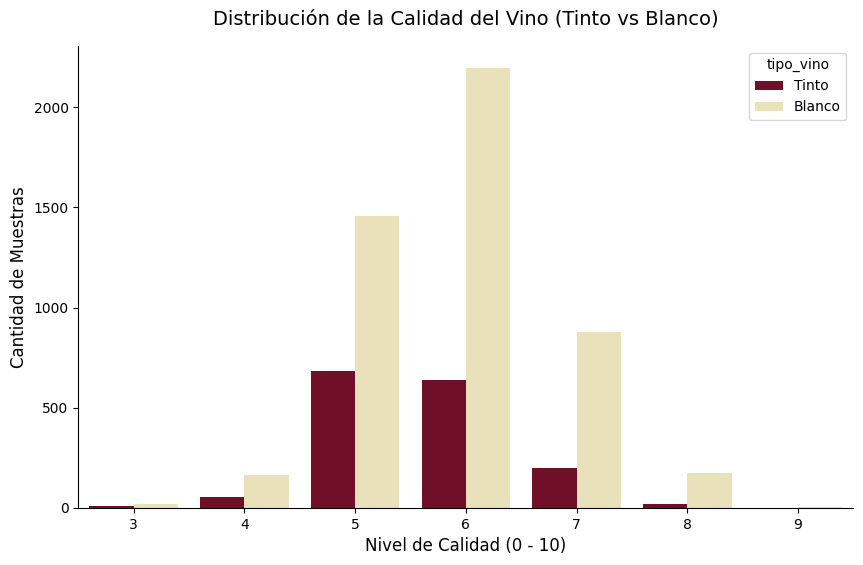

In [26]:
df_red['tipo_vino'] = 'Tinto'
df_white['tipo_vino'] = 'Blanco'

df_vinos = pd.concat([df_red, df_white], ignore_index=True)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_vinos,
    x='quality',
    hue='tipo_vino',
    palette={'Tinto': '#800020', 'Blanco': '#f1e6b2'}
)


plt.title('Distribución de la Calidad del Vino (Tinto vs Blanco)', fontsize=14, pad=15)
plt.xlabel('Nivel de Calidad (0 - 10)', fontsize=12)
plt.ylabel('Cantidad de Muestras', fontsize=12)


sns.despine()

plt.show()